In [1]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import numpy as np

In [2]:
import mplhep as hep
plt.style.use(hep.style.CMS) 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[0 1 2 3 4 5]


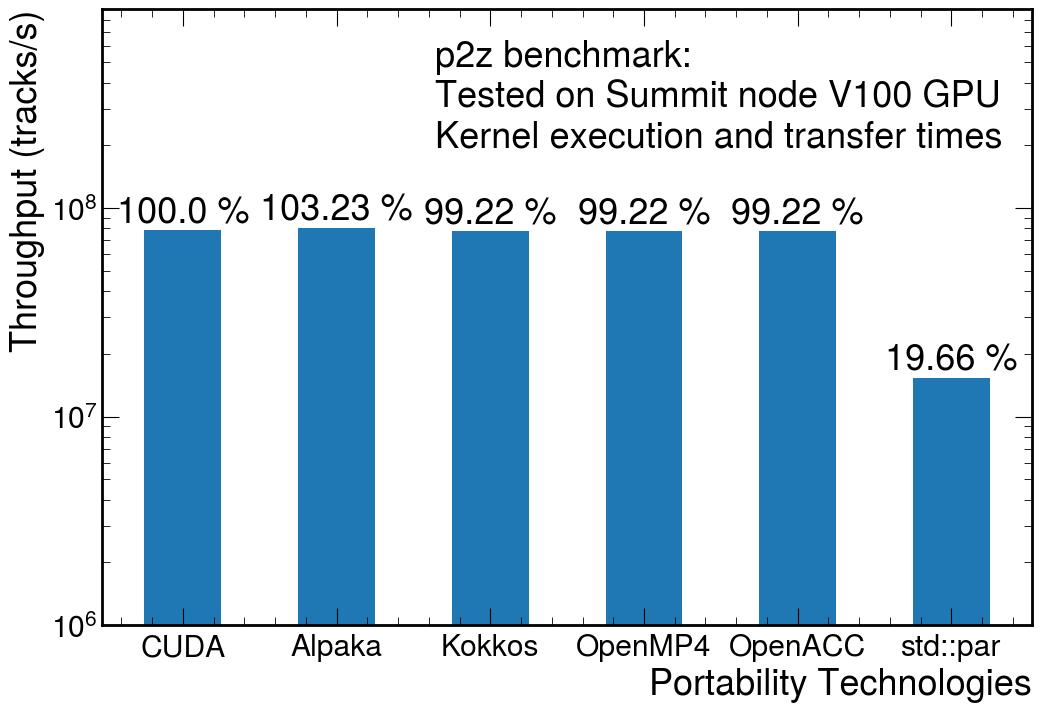

<Figure size 1000x1000 with 0 Axes>

In [3]:
p2z_data = {"CUDA": 1.28E-08,"Alpaka":1.24E-08,"Kokkos":1.29E-08,"OpenMP4":1.29E-08,"OpenACC":1.29E-08, "std::par":6.51E-08}

xlabels=[]
data_a =[]
for i in p2z_data:
    xlabels.append(i)
    data_a.append(1./p2z_data[i])
    
data = np.array(data_a)

data_fraction = [ '%s %%'%d for d in np.round(100*data/data[0],2)]


fig, ax = plt.subplots(figsize=(12,8))

widths = np.array([5,6,6])

x_pos = np.arange(len(xlabels))

print(x_pos)
# print(np.round(data/data[0],2)*)
ax.legend(title="p2z benchmark:\nTested on Summit node V100 GPU\nKernel execution and transfer times")

bars = ax.bar(x_pos,data,width=0.5)
ax.bar_label(bars, labels=data_fraction)
ax.set_xticks(x_pos)
ax.set_xticklabels(xlabels)
ax.set_xlabel("Portability Technologies")
# ax.set_ylim(0,6.5e8)
ax.set_ylim(1e6,9e8)
ax.set_yscale("log")
ax.set_ylabel("Throughput (tracks/s)")

plt.show()
plt.tight_layout()
fig.savefig("p2z-GPU.pdf",bbox_inches = 'tight')


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[0 1 2 3 4 5]


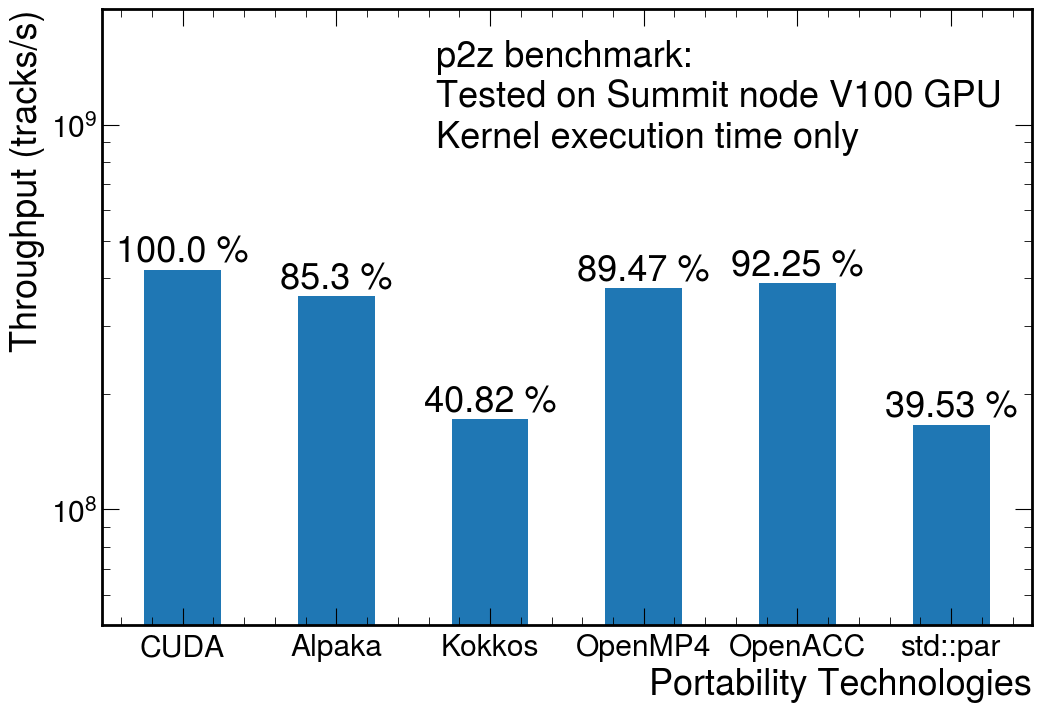

<Figure size 1000x1000 with 0 Axes>

In [4]:
p2z_data = {"CUDA": 2.38E-09,"Alpaka":2.79E-09,"Kokkos":5.83E-09,"OpenMP4":2.66E-09,"OpenACC":2.58E-09,"std::par":6.02E-09}

xlabels=[]
data_a =[]
for i in p2z_data:
    xlabels.append(i)
    data_a.append(1./p2z_data[i])
    
data = np.array(data_a)

data_fraction = [ '%s %%'%d for d in np.round(100*data/data[0],2)]


fig, ax = plt.subplots(figsize=(12,8))

widths = np.array([5,6,6])

x_pos = np.arange(len(xlabels))

print(x_pos)
# print(np.round(data/data[0],2)*)
ax.legend(title="p2z benchmark:\nTested on Summit node V100 GPU\nKernel execution time only")

bars = ax.bar(x_pos,data,width=0.5)
ax.bar_label(bars, labels=data_fraction)
ax.set_xticks(x_pos)
ax.set_xticklabels(xlabels)
ax.set_xlabel("Portability Technologies")
# ax.set_ylim(0,6.5e8)
ax.set_ylim(5e7,2e9)
ax.set_yscale("log")
ax.set_ylabel("Throughput (tracks/s)")

plt.show()
plt.tight_layout()
fig.savefig("p2z-GPU-KernelOnly.pdf",bbox_inches = 'tight')


# Performance with prepinning

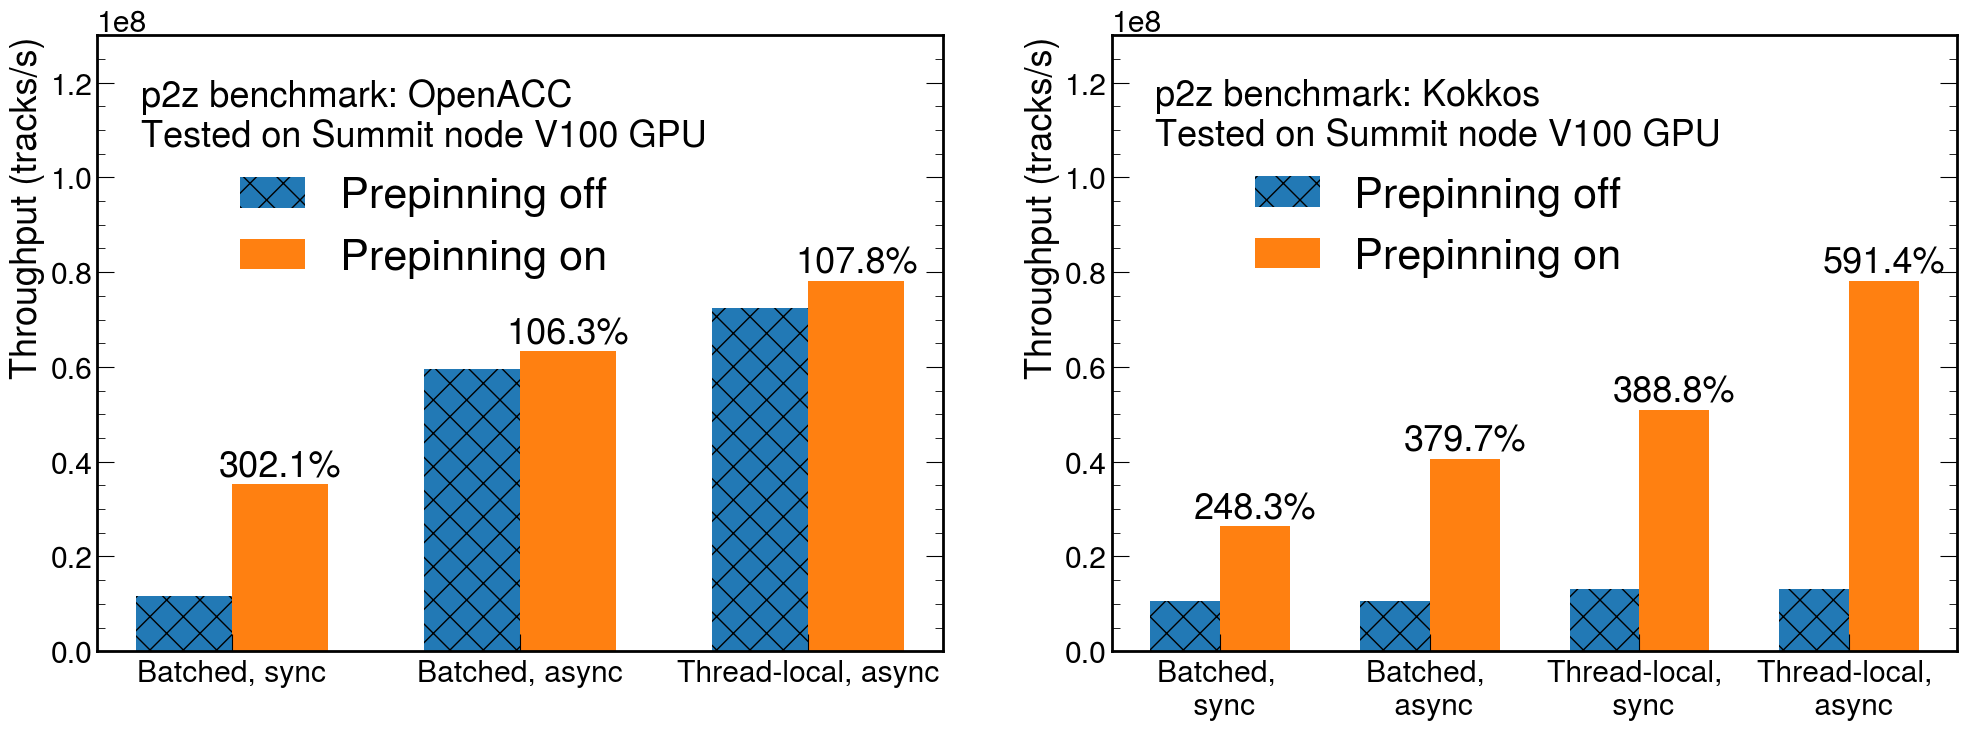

<Figure size 1000x1000 with 0 Axes>

In [65]:

#Set the width of the bars
width = 0.35

fig = plt.subplots(1, 2, figsize=(24, 8))

ax = plt.subplot(1, 2, 1)

data_acc = {"  Off":8.58E-08,"  On":2.84E-08,} #Batched shared data on shared memory, sync
data_accv3 = {"  Off":1.68E-08,"  On":1.58E-08,} #Batched shared data on shared memory, async
data_accv4 = {"  Off":1.38E-08,"  On":1.28E-08,} #Thread-private data on local memory, async

labels=[]

data_temp =[]
for i in data_acc:
    labels.append(i)
    data_temp.append(1./data_acc[i])
    
data_acc_np = np.array(data_temp)
data_fractionAcc = [ '%s %%'%d for d in np.round(100*data_acc_np/data_acc_np[0],2)]

    
data_temp =[]
for i in data_accv3:
    labels.append(i)
    data_temp.append(1./data_accv3[i])
    
data_accv3_np = np.array(data_temp)
data_fractionAccv3 = [ '%s %%'%d for d in np.round(100*data_accv3_np/data_accv3_np[0],2)]

data_temp =[]
for i in data_accv4:
    labels.append(i)
    data_temp.append(1./data_accv4[i])
    
data_accv4_np = np.array(data_temp)
data_fractionAccv4 = [ '%s %%'%d for d in np.round(100*data_accv4_np/data_accv4_np[0],2)]


data = np.concatenate((data_acc_np, data_accv3_np, data_accv4_np))
data_fraction = data_fractionAcc + data_fractionAccv3 + data_fractionAccv4

#data    = np.array([7.75E-08,8.01E-08,2.44E-08, 1.09E-07, 2.44E-08])
#labels = [" LLVM"," IBM"," OpenARC"," nvhpc"," OpenARC"]
x_label= ["Batched, sync","Batched, async","Thread-local, async"]

x=[width, 2*width, 4*width, 5*width, 7*width, 8*width]
#for i in range(len(p2z_compiler_data_OpenMP4)):
#    x.append(1+(i)*width)
#for i in range(len(p2z_compiler_data_OpenACC)):
#    start = len(p2z_compiler_data_OpenMP4)+1
#    x.append(1+(i+start)*width)

#x      = [1,1+width,1+2*width,1+4*width,1+5*width]
x_ticks = [1.5*width,4.5*width,7.5*width]

#bars = ax.bar(x , data, width)
odd = ax.bar(x[::2] , data[::2], width,label="Prepinning off",hatch='x',alpha=0.99)
even = ax.bar(x[1::2] , data[1::2],  width,label="Prepinning on",hatch='',alpha=0.99)

data_fraction = [ '%s%%'%d for d in np.round(100*data[1::2]/data[::2],1)]
ax.bar_label(even, labels=data_fraction)#, rotation=90)

#x.bar_label(bars, labels=labels, rotation=90)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_label) 
ax.tick_params(top=False)
ax.xaxis.set_minor_locator(AutoMinorLocator(1))
#ax.set_yscale("log")
ax.set_ylabel("Throughput (tracks/s)")
#ax.set_ylim(8e6,2e8)
ax.set_ylim(0,1.3e8)

ax.legend(title="p2z benchmark: OpenACC\nTested on Summit node V100 GPU",fontsize="large",loc="upper left")

######################################
######################################
######################################
######################################

ax = plt.subplot(1, 2, 2)

data_v3 = {"  Off":9.41E-08,"  On":3.79E-08,} #Batched shared data on shared memory, sync
data_v4 = {"  Off":9.34E-08,"  On":2.46E-08,} #Batched shared data on shared memory, async, 8 streams
data_v5 = {"  Off":7.62E-08,"  On":1.96E-08,} #Thread-private data on local memory, sync
data_v6 = {"  Off":7.57E-08,"  On":1.28E-08,} #Thread-private data on local memory, async

labels=[]

data_temp =[]
for i in data_v3:
    labels.append(i)
    data_temp.append(1./data_v3[i])
for i in data_v4:
    labels.append(i)
    data_temp.append(1./data_v4[i])
for i in data_v5:
    labels.append(i)
    data_temp.append(1./data_v5[i])
for i in data_v6:
    labels.append(i)
    data_temp.append(1./data_v6[i])
    
data = np.array(data_temp)


x_label= ["Batched, \n sync","Batched, \n async","Thread-local, \n sync","Thread-local, \n async"]

x=[width, 2*width, 4*width, 5*width, 7*width, 8*width, 10*width, 11*width]

x_ticks = [1.5*width,4.5*width,7.5*width, 10.5*width]

#bars = ax.bar(x , data, width)
#ax.bar_label(bars, labels=labels, rotation=90)
odd = ax.bar(x[::2] , data[::2], width,label="Prepinning off",hatch='x',alpha=0.99)
even = ax.bar(x[1::2] , data[1::2],  width,label="Prepinning on",hatch='',alpha=0.99)

data_fraction = [ '%s%%'%d for d in np.round(100*data[1::2]/data[::2],1)]
ax.bar_label(even, labels=data_fraction)#, rotation=90)


# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_label)
ax.tick_params(top=False)
ax.xaxis.set_minor_locator(AutoMinorLocator(1))

#ax.set_yscale("log")
ax.set_ylabel("Throughput (tracks/s)")
#ax.set_ylim(8e6,2e8)
ax.set_ylim(0,1.3e8)
#ax.legend(title="p2z benchmark:\nTested on Summit node V100 GPU\nKokkos",fontsize="xx-large")
ax.legend(title="p2z benchmark: Kokkos\nTested on Summit node V100 GPU",fontsize="large",loc="upper left")

# Show the plot
plt.savefig("p2z-GPU-prepinning.pdf",bbox_inches = 'tight')
plt.show()
plt.tight_layout()


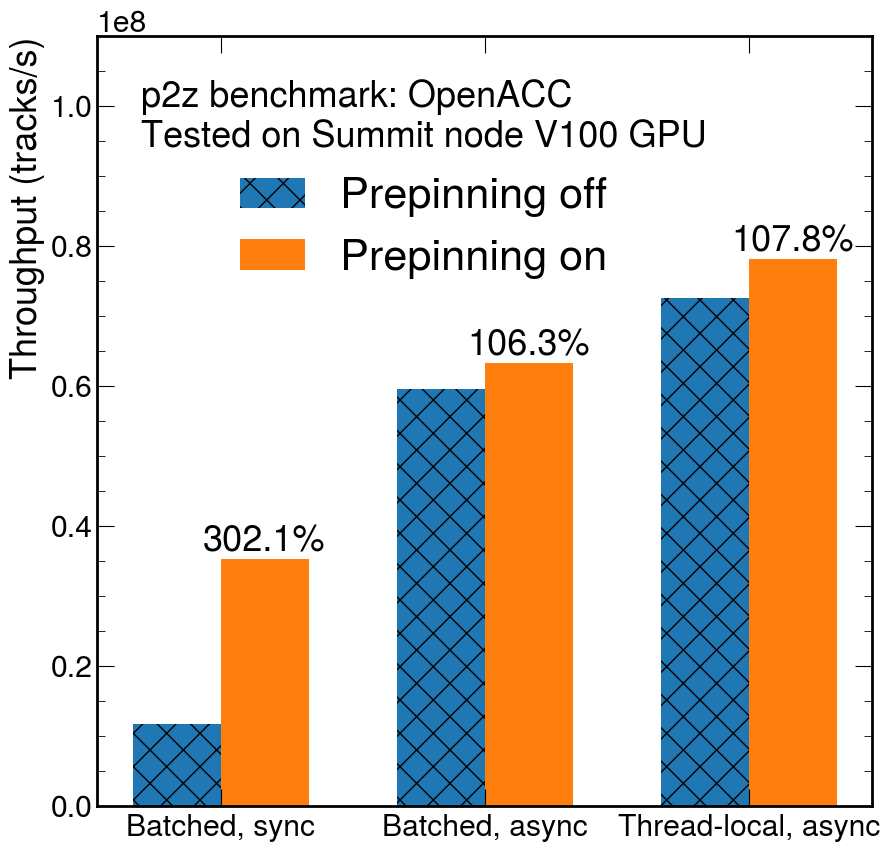

<Figure size 1000x1000 with 0 Axes>

In [46]:
#Set the width of the bars
width = 0.35

data_acc = {"  Off":8.58E-08,"  On":2.84E-08,} #Batched shared data on shared memory, sync
data_accv3 = {"  Off":1.68E-08,"  On":1.58E-08,} #Batched shared data on shared memory, async
data_accv4 = {"  Off":1.38E-08,"  On":1.28E-08,} #Thread-private data on local memory, async

labels=[]

data_temp =[]
for i in data_acc:
    labels.append(i)
    data_temp.append(1./data_acc[i])
    
data_acc_np = np.array(data_temp)
data_fractionAcc = [ '%s %%'%d for d in np.round(100*data_acc_np/data_acc_np[0],2)]

    
data_temp =[]
for i in data_accv3:
    labels.append(i)
    data_temp.append(1./data_accv3[i])
    
data_accv3_np = np.array(data_temp)
data_fractionAccv3 = [ '%s %%'%d for d in np.round(100*data_accv3_np/data_accv3_np[0],2)]

data_temp =[]
for i in data_accv4:
    labels.append(i)
    data_temp.append(1./data_accv4[i])
    
data_accv4_np = np.array(data_temp)
data_fractionAccv4 = [ '%s %%'%d for d in np.round(100*data_accv4_np/data_accv4_np[0],2)]


data = np.concatenate((data_acc_np, data_accv3_np, data_accv4_np))
data_fraction = data_fractionAcc + data_fractionAccv3 + data_fractionAccv4

#data    = np.array([7.75E-08,8.01E-08,2.44E-08, 1.09E-07, 2.44E-08])
#labels = [" LLVM"," IBM"," OpenARC"," nvhpc"," OpenARC"]
x_label= ["Batched, sync","Batched, async","Thread-local, async"]

x=[width, 2*width, 4*width, 5*width, 7*width, 8*width]
#for i in range(len(p2z_compiler_data_OpenMP4)):
#    x.append(1+(i)*width)
#for i in range(len(p2z_compiler_data_OpenACC)):
#    start = len(p2z_compiler_data_OpenMP4)+1
#    x.append(1+(i+start)*width)

#x      = [1,1+width,1+2*width,1+4*width,1+5*width]
x_ticks = [1.5*width,4.5*width,7.5*width]

fig, ax = plt.subplots()

#bars = ax.bar(x , data, width)
odd = ax.bar(x[::2] , data[::2], width,label="Prepinning off",hatch='x')
even = ax.bar(x[1::2] , data[1::2],  width,label="Prepinning on",hatch='')

data_fraction = [ '%s%%'%d for d in np.round(100*data[1::2]/data[::2],1)]
ax.bar_label(even, labels=data_fraction)#, rotation=90)

#x.bar_label(bars, labels=labels, rotation=90)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_label) 
ax.xaxis.set_minor_locator(AutoMinorLocator(1))
#ax.set_yscale("log")
ax.set_ylabel("Throughput (tracks/s)")
#ax.set_ylim(8e6,2e8)
ax.set_ylim(0,1.1e8)

ax.legend(title="p2z benchmark: OpenACC\nTested on Summit node V100 GPU",fontsize="large",loc="upper left")

# Show the plot
plt.show()
plt.tight_layout()
fig.savefig("p2z-GPU-prepinning-OpenACC.pdf",bbox_inches = 'tight')

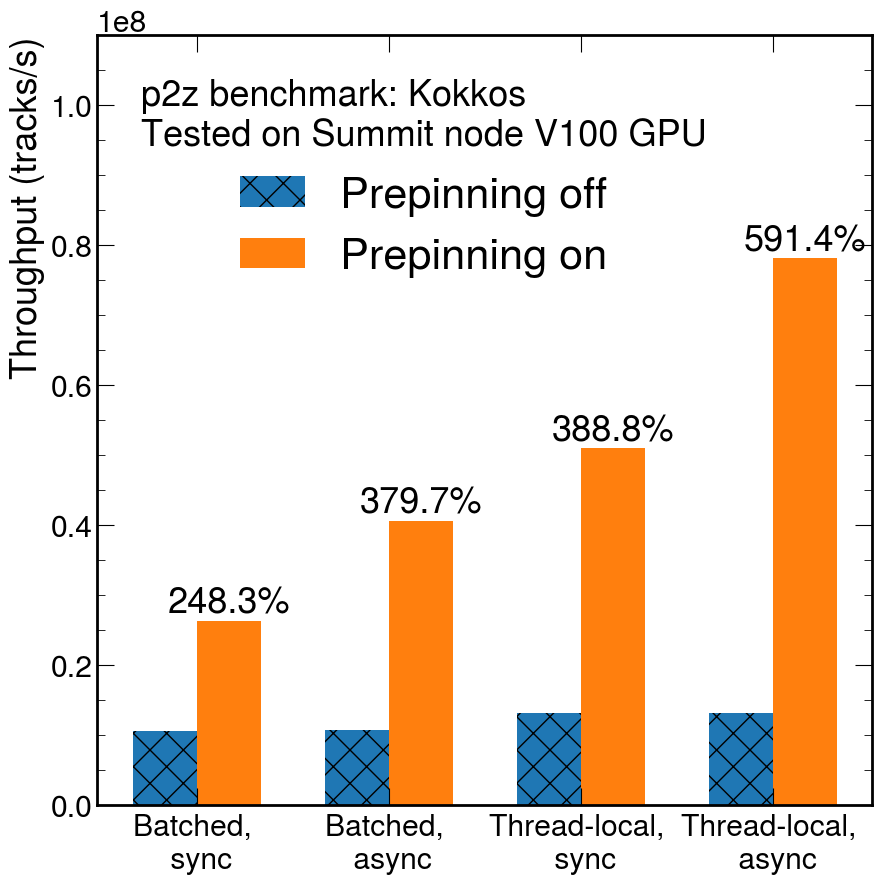

<Figure size 1000x1000 with 0 Axes>

In [47]:

#Set the width of the bars
width = 0.35

data_v3 = {"  Off":9.41E-08,"  On":3.79E-08,} #Batched shared data on shared memory, sync
data_v4 = {"  Off":9.34E-08,"  On":2.46E-08,} #Batched shared data on shared memory, async, 8 streams
data_v5 = {"  Off":7.62E-08,"  On":1.96E-08,} #Thread-private data on local memory, sync
data_v6 = {"  Off":7.57E-08,"  On":1.28E-08,} #Thread-private data on local memory, async

labels=[]

data_temp =[]
for i in data_v3:
    labels.append(i)
    data_temp.append(1./data_v3[i])
for i in data_v4:
    labels.append(i)
    data_temp.append(1./data_v4[i])
for i in data_v5:
    labels.append(i)
    data_temp.append(1./data_v5[i])
for i in data_v6:
    labels.append(i)
    data_temp.append(1./data_v6[i])
    
data = np.array(data_temp)
 

x_label= ["Batched, \n sync","Batched, \n async","Thread-local, \n sync","Thread-local, \n async"]

x=[width, 2*width, 4*width, 5*width, 7*width, 8*width, 10*width, 11*width]

x_ticks = [1.5*width,4.5*width,7.5*width, 10.5*width]

fig, ax = plt.subplots()

#bars = ax.bar(x , data, width)
#ax.bar_label(bars, labels=labels, rotation=90)
odd = ax.bar(x[::2] , data[::2], width,label="Prepinning off",hatch='x')
even = ax.bar(x[1::2] , data[1::2],  width,label="Prepinning on",hatch='')

data_fraction = [ '%s%%'%d for d in np.round(100*data[1::2]/data[::2],1)]
ax.bar_label(even, labels=data_fraction)#, rotation=90)


# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_label)
ax.xaxis.set_minor_locator(AutoMinorLocator(1))

#ax.set_yscale("log")
ax.set_ylabel("Throughput (tracks/s)")
#ax.set_ylim(8e6,2e8)
ax.set_ylim(0,1.1e8)
#ax.legend(title="p2z benchmark:\nTested on Summit node V100 GPU\nKokkos",fontsize="xx-large")
ax.legend(title="p2z benchmark: Kokkos\nTested on Summit node V100 GPU",fontsize="large",loc="upper left")

# Show the plot
plt.show()
plt.tight_layout()
fig.savefig("p2z-GPU-prepinning-Kokkos.pdf",bbox_inches = 'tight')

# Performance vs compilers

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


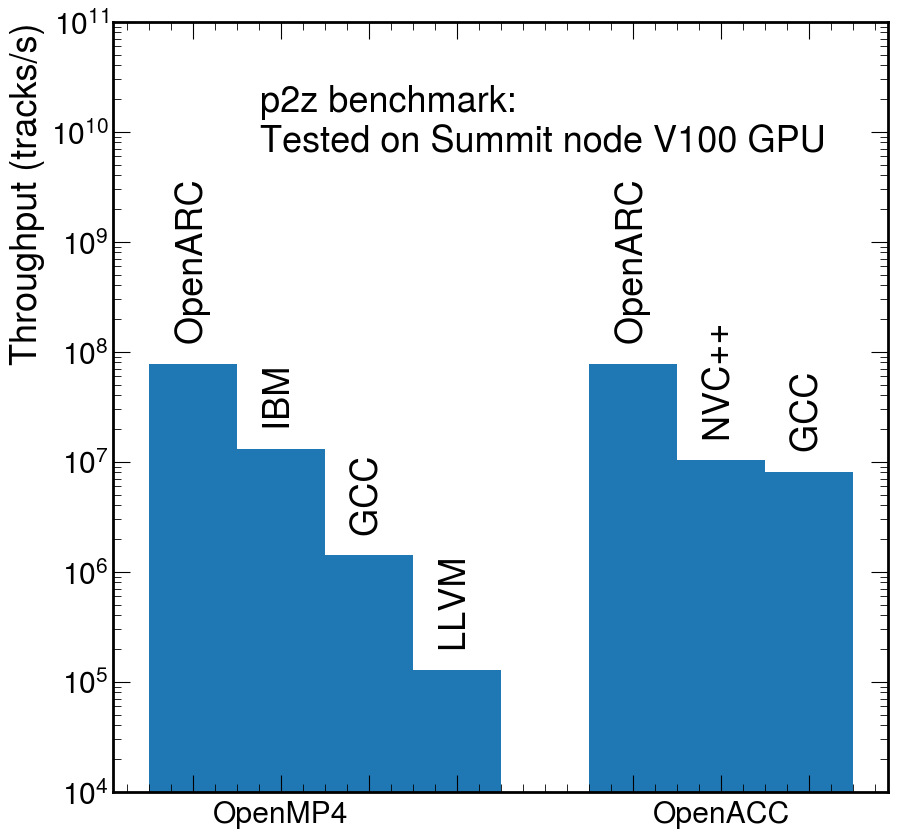

<Figure size 1000x1000 with 0 Axes>

In [16]:
#Set the width of the bars
width = 0.35

p2z_compiler_data_OpenMP4 = {"  OpenARC":1.29E-08,"  IBM":7.72E-08,"  GCC":7.06E-07,"  LLVM":7.90E-06}
p2z_compiler_data_OpenACC = {"  OpenARC":1.29E-08,"  NVC++":9.67E-08,"  GCC":1.23E-07,}

labels=[]

data_a =[]
for i in p2z_compiler_data_OpenMP4:
    labels.append(i)
    data_a.append(1./p2z_compiler_data_OpenMP4[i])
    
dataOpenMP = np.array(data_a)
data_fractionOpenMP = [ '%s %%'%d for d in np.round(100*dataOpenMP/dataOpenMP[0],2)]

    
data_a =[]
for i in p2z_compiler_data_OpenACC:
    labels.append(i)
    data_a.append(1./p2z_compiler_data_OpenACC[i])

dataOpenACC = np.array(data_a)
data_fractionOpenACC = [ '%s %%'%d for d in np.round(100*dataOpenACC/dataOpenACC[0],2)]


data = np.concatenate((dataOpenMP,dataOpenACC))
data_fraction = data_fractionOpenMP + data_fractionOpenACC

#data    = np.array([7.75E-08,8.01E-08,2.44E-08, 1.09E-07, 2.44E-08])
#labels = [" LLVM"," IBM"," OpenARC"," nvhpc"," OpenARC"]
x_label= ["","OpenMP4","","","","OpenACC",""]

x=[]
for i in range(len(p2z_compiler_data_OpenMP4)):
    x.append(1+(i)*width)
for i in range(len(p2z_compiler_data_OpenACC)):
    start = len(p2z_compiler_data_OpenMP4)+1
    x.append(1+(i+start)*width)

#x      = [1,1+width,1+2*width,1+4*width,1+5*width]
xticks = [1,1+width,1+2*width,1+5.5*width]

fig, ax = plt.subplots()

bars = ax.bar(x , data, width)
ax.bar_label(bars, labels=labels, rotation=90)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xticks(x)
ax.set_xticklabels(x_label)
ax.set_yscale("log")
ax.set_ylabel("Throughput (tracks/s)")
ax.set_ylim(1e4,1e11)
ax.legend(title="p2z benchmark:\nTested on Summit node V100 GPU",fontsize="xx-large")

# Show the plot
plt.show()
plt.tight_layout()
fig.savefig("p2z-GPU-compilers.pdf",bbox_inches = 'tight')

In [50]:
#Set the width of the bars
width = 0.35

p2z_compiler_data_OpenACC = {"OpenARC":1.29E-08,"NVHPC":9.67E-08,"GCC":1.23E-07,}
p2z_compiler_data_OpenMP4 = {"OpenARC":1.29E-08,"IBM":7.72E-08,"GCC":7.06E-07,"LLVM":7.90E-06}

labels=[]
data_a =[]
for i in p2z_compiler_data_OpenACC:
    labels.append(i)
    data_a.append(1./p2z_compiler_data_OpenACC[i])

dataOpenACC = np.array(data_a)
data_fractionOpenACC = [ '%s %%'%d for d in np.round(100*dataOpenACC/dataOpenACC[0],2)]

data_a =[]

for i in p2z_compiler_data_OpenMP4:
    labels.append(i)
    data_a.append(1./p2z_compiler_data_OpenMP4[i])

dataOpenMP = np.array(data_a)
data_fractionOpenMP = [ '%s %%'%d for d in np.round(100*dataOpenMP/dataOpenMP[0],2)]


#data = dataOpenACC + dataOpenMP
data_fraction = data_fractionOpenACC + data_fractionOpenMP
print(data_fraction)
data = np.concatenate((dataOpenACC,dataOpenMP))
print(np.concatenate((dataOpenACC,dataOpenMP)))

print(len(p2z_compiler_data_OpenMP4))

x=[1.]
for i in range(len(p2z_compiler_data_OpenACC)):
    x.append(1+(i+1)*width)
for i in range(len(p2z_compiler_data_OpenMP4)-1):
    start = len(p2z_compiler_data_OpenACC)+2
    x.append(1+(i+start)*width)
print(x)
print(len(x))
print(len(data))

['100.0 %', '13.34 %', '10.49 %', '100.0 %', '16.71 %', '1.83 %', '0.16 %']
[77519379.84496124 10341261.63391934  8130081.30081301 77519379.84496124
 12953367.87564767  1416430.59490085   126582.27848101]
4
[1.0, 1.35, 1.7, 2.05, 2.75, 3.0999999999999996, 3.4499999999999997]
7
7


# Original plots

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[0 1 2 3 4 5]


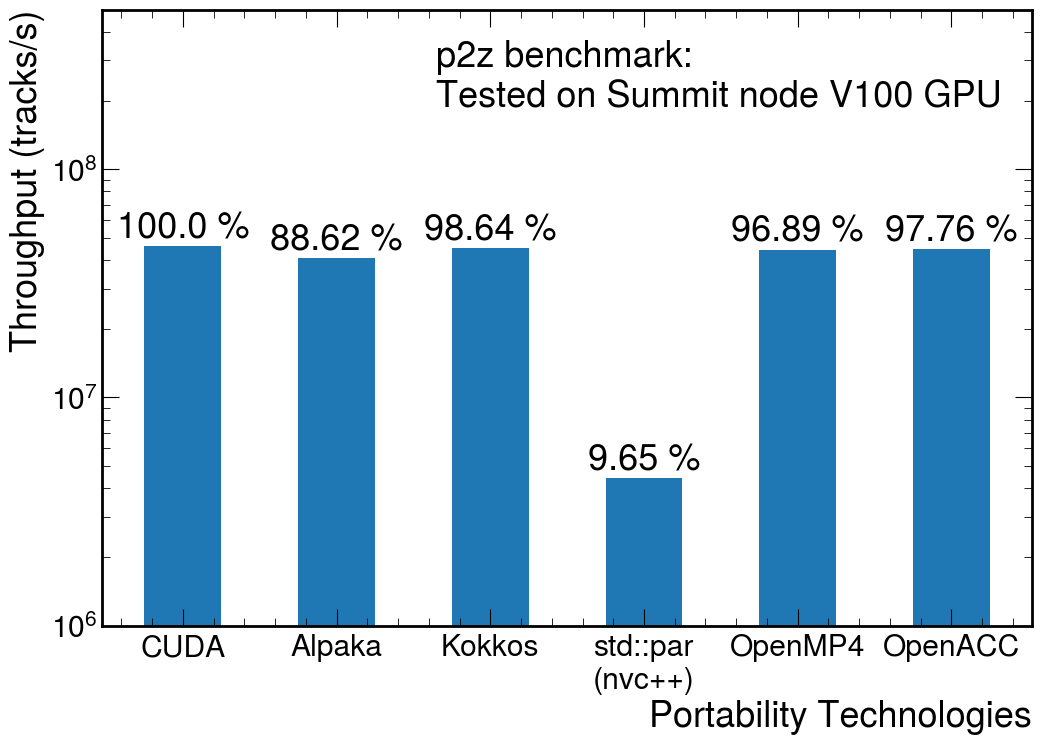

<Figure size 1000x1000 with 0 Axes>

In [3]:
fig, ax = plt.subplots(figsize=(12,8))

widths = np.array([5,5,5])
xlabels = [
           "CUDA",
           "Alpaka",
           "Kokkos",
           "std::par\n(nvc++)",
           "OpenMP4",
            "OpenACC",
          ]

data      = np.array([2.18E-08,2.46E-08,2.21E-08,2.26E-07,2.25E-08,2.23E-08])

data = 1./data

data_fraction = [ '%s %%'%d for d in np.round(100*data/data[0],2)]
x_pos = np.arange(len(xlabels))

print(x_pos)
# print(np.round(data/data[0],2)*)
ax.legend(title="p2z benchmark:\nTested on Summit node V100 GPU")

bars = ax.bar(x_pos,data,width=0.5)
ax.bar_label(bars, labels=data_fraction)
ax.set_xticks(x_pos)
ax.set_xticklabels(xlabels)
ax.set_xlabel("Portability Technologies")
# ax.set_ylim(0,6.5e8)
ax.set_ylim(1e6,5e8)
ax.set_yscale("log")
ax.set_ylabel("Throughput (tracks/s)")

plt.show()
plt.tight_layout()
fig.savefig("p2z-CUDA.pdf",bbox_inches = 'tight')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[0 1 2 3 4 5]


Text(0, 1, 'Throughput (tracks/s)')

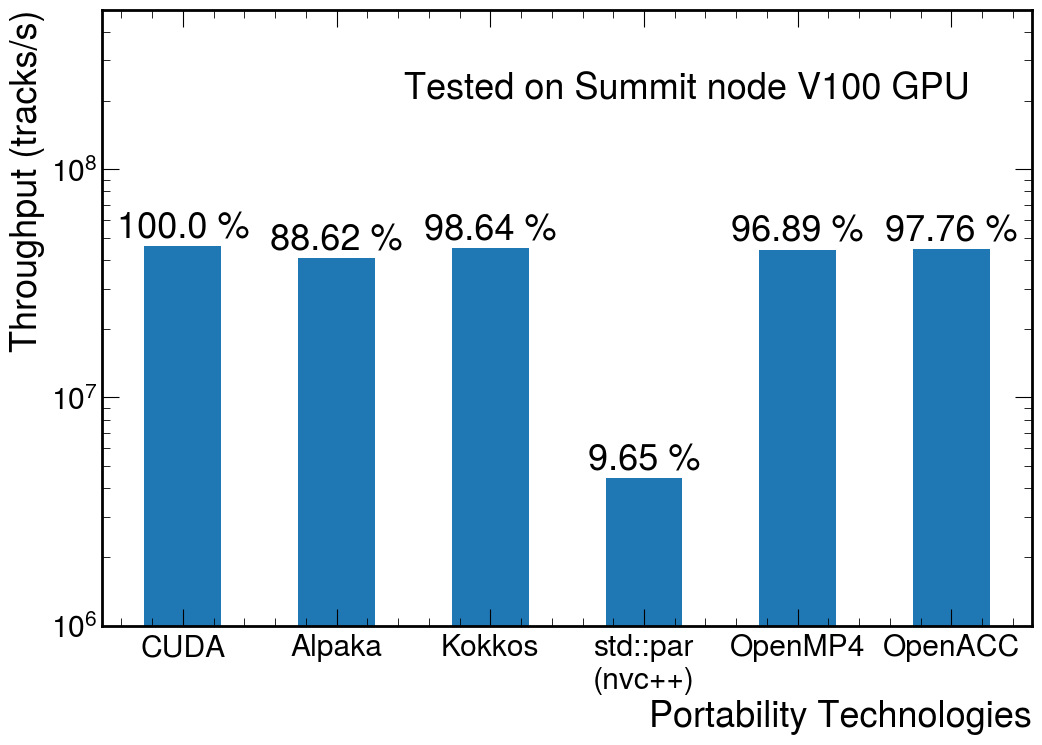

In [4]:
fig, ax = plt.subplots(figsize=(12,8))

widths = np.array([5,6,6])
xlabels = [
           "CUDA",
           "Alpaka",
           "Kokkos",
           "std::par\n(nvc++)",
           "OpenMP4",
            "OpenACC",
          ]

1.09E-07,2.44E-08,

7.75E-08
8.01E-08
2.44E-08
data      = np.array([2.18E-08,2.46E-08,2.21E-08,2.26E-07,2.25E-08,2.23E-08])

data = 1./data

data_fraction = [ '%s %%'%d for d in np.round(100*data/data[0],2)]
x_pos = np.arange(len(xlabels))

print(x_pos)
# print(np.round(data/data[0],2)*)
ax.legend(title="Tested on Summit node V100 GPU",fontsize="xx-large")

bars = ax.bar(x_pos,data,width=0.5)
ax.bar_label(bars, labels=data_fraction)
ax.set_xticks(x_pos)
ax.set_xticklabels(xlabels)
ax.set_xlabel("Portability Technologies")
# ax.set_ylim(0,6.5e8)
ax.set_ylim(1e6,5e8)
ax.set_yscale("log")
ax.set_ylabel("Throughput (tracks/s)")


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[0 1 2 3 4]


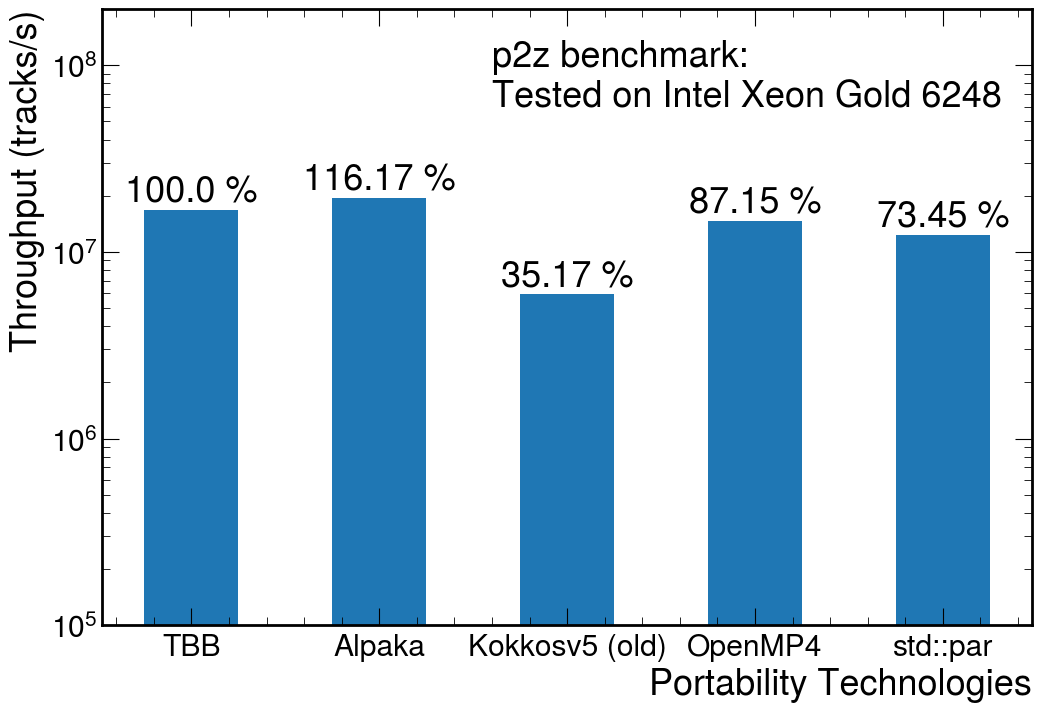

<Figure size 1000x1000 with 0 Axes>

In [5]:
fig, ax = plt.subplots(figsize=(12,8))

widths = np.array([5,6,6])
xlabels = [
           "TBB",
           "Alpaka",
           "Kokkosv5 (old)",
           "OpenMP4",
            "std::par"
          # "OpenACC",
          # "Eigen",
          ]
#data      = np.array([8.23E-08,1.40E-07,1.69E-07,1.15E-07,4.28E-07,1.70E-07])

#data = np.array([8.024819e-08,5.6062E-8,7.557265E-7,1.06795E-7,8.7908E-8])

#New results from Alexei, 3/6/24 missing Kokkos (placeholder for now)
data = np.array([5.943281e-08,5.116052e-08,1.69E-07,6.819333e-08,8.091990e-08])

data = 1./data


data_fraction = [ '%s %%'%d for d in np.round(100*data/data[0],2)]
x_pos = np.arange(len(xlabels))

print(x_pos)
# print(np.round(data/data[0],2)*)
ax.legend(title="p2z benchmark:\nTested on Intel Xeon Gold 6248")#,fontsize="xx-large")

bars = ax.bar(x_pos,data,width=0.5)
ax.bar_label(bars, labels=data_fraction)
ax.set_xticks(x_pos)
ax.set_xticklabels(xlabels)
ax.set_xlabel("Portability Technologies")
# ax.set_ylim(0,6.5e8)
ax.set_ylim(1e5,2e8)
ax.set_yscale("log")
ax.set_ylabel("Throughput (tracks/s)")

plt.show()
plt.tight_layout()
fig.savefig("p2z-CPU.pdf",bbox_inches = 'tight')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


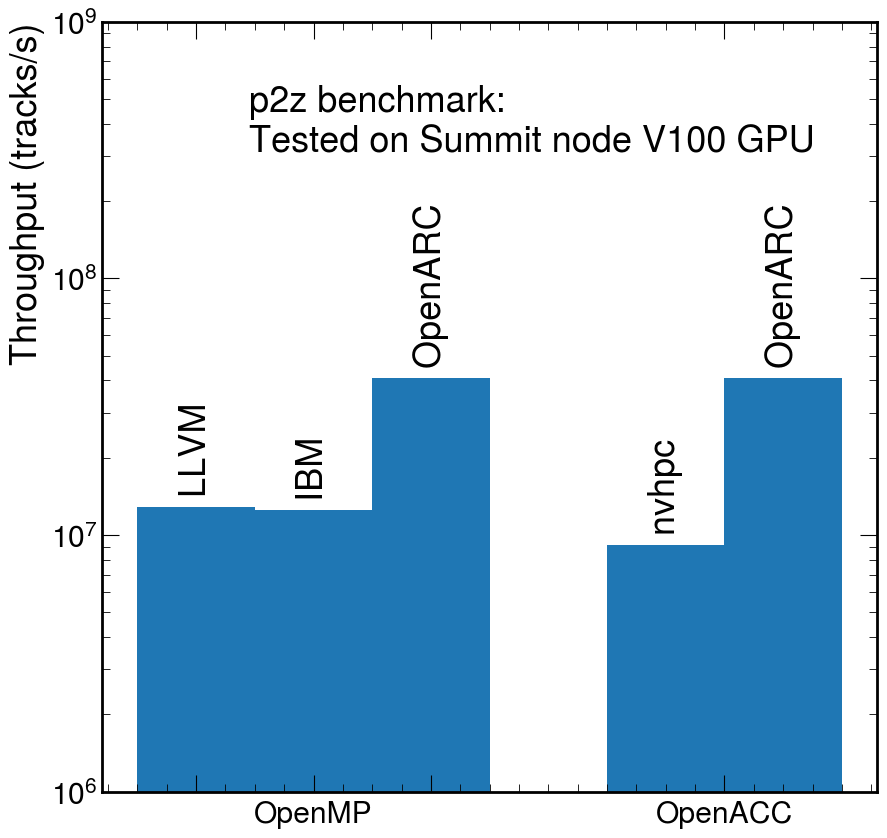

<Figure size 1000x1000 with 0 Axes>

In [6]:
# Set the width of the bars
width = 0.35

data    = np.array([7.75E-08,8.01E-08,2.44E-08, 1.09E-07, 2.44E-08])
labels = [" LLVM"," IBM"," OpenARC"," nvhpc"," OpenARC"]
x_label= ["","OpenMP","","OpenACC"]
x      = [1,1+width,1+2*width,1+4*width,1+5*width]
xticks = [1,1+width,1+2*width,1+4.5*width]

fig, ax = plt.subplots()

bars = ax.bar(x , 1./data, width)
ax.bar_label(bars, labels=labels, rotation=90)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xticks(xticks)
ax.set_xticklabels(x_label)
ax.set_yscale("log")
ax.set_ylabel("Throughput (tracks/s)")
ax.set_ylim(1e6,1e9)
ax.legend(title="p2z benchmark:\nTested on Summit node V100 GPU",fontsize="xx-large")

# Show the plot
plt.show()
plt.tight_layout()
fig.savefig("p2z-GPU-vars.pdf",bbox_inches = 'tight')

In [84]:
x[1::2]

[1.35, 2.4, 3.4499999999999997]

In [83]:
x[::2]

[1, 2.05, 3.0999999999999996]

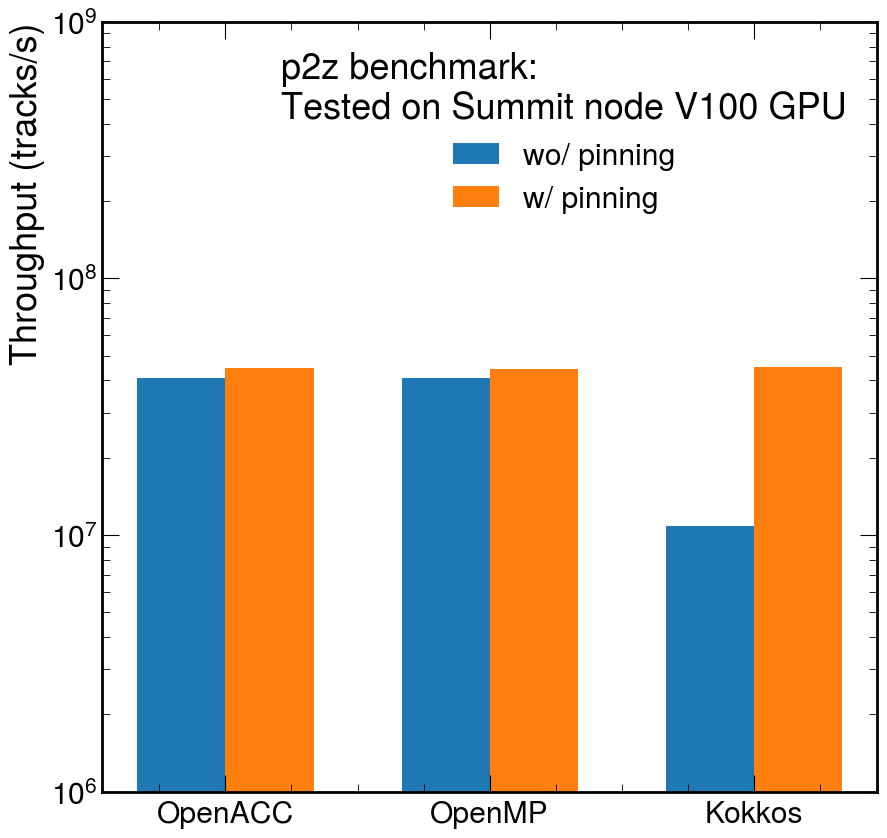

<Figure size 1000x1000 with 0 Axes>

In [7]:
# Set the width of the bars
width = 0.35

data    = np.array([2.44E-08,2.23E-08,
                   2.44E-08,2.25E-08,
                   9.23E-08,2.21E-08])
x      = [1,1+width,1+3*width,1+4*width,1+6*width,1+7*width]
# labels = [" LLVM"," IBM"," OpenARC"," nvhpc"," OpenARC"]
x_label= ["OpenACC","OpenMP","Kokkos"]

xticks = [1+0.5*width,1+3.5*width,1+6.5*width]

fig, ax = plt.subplots()

odd = ax.bar(x[::2] , 1./data[::2], width,label="wo/ pinning")
even = ax.bar(x[1::2] , 1./data[1::2], width,label="w/ pinning")
# ax.bar_label(bars, labels=labels, rotation=90)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xticks(xticks)
ax.set_xticklabels(x_label)
ax.set_yscale("log")
ax.set_ylabel("Throughput (tracks/s)")
ax.set_ylim(1e6,1e9)
# ax.legend(title_fontsize="small",title="p2z benchmark:\nTested on Summit node V100 GPU",fontsize='small')
ax.legend(title="p2z benchmark:\nTested on Summit node V100 GPU")


# Show the plot
plt.show()
plt.tight_layout()
fig.savefig("p2z-GPU-pining.pdf",bbox_inches = 'tight')